# KL-Divergence IR with NLTK

Notebook ini mendemonstrasikan ranking dokumen menggunakan KL-Divergence dengan preprocessing NLTK, tabel hasil, dan visualisasi skor.

## 1. Inisialisasi dan Resource NLTK

Bagian ini menyiapkan library dan memastikan resource NLTK yang dibutuhkan tersedia.

In [1]:

import math, re
from collections import Counter
from typing import List, Dict, Tuple, Any
import nltk
import pandas as pd
import matplotlib.pyplot as plt

# Ensure NLTK resources are available
def _ensure_nltk_resource(resource_path: str, download_name: str) -> None:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

_ensure_nltk_resource("tokenizers/punkt", "punkt")
_ensure_nltk_resource("tokenizers/punkt_tab", "punkt_tab")
_ensure_nltk_resource("corpora/stopwords", "stopwords")


In [2]:
def _tokenize(text: str) -> List[str]:
    '''Tokenize using NLTK's word_tokenize and lower‑case the result.'''
    from nltk.tokenize import word_tokenize
    return [tok.lower() for tok in word_tokenize(text)]

def _stemming(tokens: List[str]) -> List[str]:
    '''Apply Porter stemming to a list of tokens.'''

    porter = nltk.PorterStemmer()
    return [porter.stem(tok) for tok in tokens]


## 2. Tokenisasi dan Stemming

Bagian ini mengubah teks mentah menjadi token bersih yang siap dipakai untuk perhitungan skor.

In [3]:
class NltkRanker:
    def __init__(self, docs: List[str], query: str, top_n: int = 5, custom_stopwords: set[str] | None = None, alpha: float = 1.0) -> None:
        self.docs_raw = docs
        self.query_raw = query
        self.top_n = top_n
        self.alpha = alpha
        self.stopwords = custom_stopwords if custom_stopwords is not None else set(nltk.corpus.stopwords.words("english"))
        self.docs_tokens = [self._preprocess(d) for d in self.docs_raw]
        self.query_tokens = self._preprocess(self.query_raw)
        self.idf = self._compute_idf(self.docs_tokens)
        self.docs_tf = [Counter(toks) for toks in self.docs_tokens]
        self.query_tf = Counter(self.query_tokens)

    @staticmethod
    def _compute_idf(docs_tokens: List[List[str]]) -> Dict[str, float]:
        N = len(docs_tokens)
        df: Dict[str, int] = {}
        for tokens in docs_tokens:
            for term in set(tokens):
                df[term] = df.get(term, 0) + 1
        return {term: math.log(N / freq) for term, freq in df.items()}

    def _preprocess(self, text: str) -> List[str]:
        clean = re.sub(r'[^\w\s]', '', text)
        tokens = _tokenize(clean)
        filtered = [t for t in tokens if t not in self.stopwords]
        return _stemming(filtered)

    def _laplace_prob(self, term: str, tf: Counter, total_tokens: int) -> float:
        vocab_size = len(self.idf)
        count = tf.get(term, 0)
        return (count + self.alpha) / (total_tokens + self.alpha * vocab_size)

    def _score_document(self, doc_index: int) -> Tuple[float, Dict[str, float]]:
        doc_tf = self.docs_tf[doc_index]
        total_doc = sum(doc_tf.values())
        total_query = sum(self.query_tf.values())
        score = 0.0
        details: Dict[str, float] = {}
        for term, q_count in self.query_tf.items():
            idf_val = self.idf.get(term, 0.0)
            p_q = self._laplace_prob(term, self.query_tf, total_query)
            p_d = self._laplace_prob(term, doc_tf, total_doc)
            contrib = idf_val * p_q * math.log(p_q / p_d)
            details[term] = contrib
            score += contrib
        return score, details

    def rank(self) -> List[Dict[str, Any]]:
        scores = []
        for i in range(len(self.docs_raw)):
            s, details = self._score_document(i)
            scores.append((i, s, details))
        scores.sort(key=lambda x: x[1])
        top = scores[:self.top_n]
        return [{"doc_id": doc, "score": sc, "term_contributions": contrib} for doc, sc, contrib in top]


## 3. Perhitungan Skor KL-Divergence

Bagian ini mendefinisikan kelas perankingan, perhitungan probabilitas, dan skor dokumen.

In [4]:
docs = [
    "Maintaining a balanced diet rich in fiber and vitamins is essential for digestive health.",
    "Regular cardiovascular exercise can significantly reduce the risk of heart disease.",
    "Mental health is just as important as physical health for overall well‑being.",
    "Getting at least eight hours of sleep helps the body repair tissues and boost the immune system.",
    "Chronic stress can lead to high blood pressure and other long‑term health complications.",
    "Drinking enough water throughout the day is crucial for maintaining proper organ function.",
    "Vaccinations are a key public health tool in preventing the spread of infectious diseases.",
    "Practicing mindfulness and meditation can help manage anxiety and improve mental clarity.",
    "Sugar consumption should be limited to prevent the onset of type 2 diabetes and obesity.",
    "Early detection through regular medical check‑ups can improve the success rate of cancer treatments."
]
query = "how to prevent diseases and improve the body's immune system through lifestyle"

## 4. Dataset dan Query

Bagian ini menyiapkan dokumen contoh dan query yang akan diranking.

In [5]:
ranker = NltkRanker(docs, query, top_n=3)

In [6]:
# Show all documents in a table
df_all = pd.DataFrame({
    "doc_id": range(len(docs)),
    "text": docs
})
df_all

,doc_id,text
0,0,Maintaining a balanced diet rich in fiber and ...
1,1,Regular cardiovascular exercise can significan...
2,2,Mental health is just as important as physical...
3,3,Getting at least eight hours of sleep helps th...
4,4,Chronic stress can lead to high blood pressure...
5,5,Drinking enough water throughout the day is cr...
6,6,Vaccinations are a key public health tool in p...
7,7,Practicing mindfulness and meditation can help...
8,8,Sugar consumption should be limited to prevent...
9,9,Early detection through regular medical check‑...


In [7]:
# Run ranking
results = ranker.rank()

In [14]:
# Top‑N results table
df_top = pd.DataFrame(results)
df_top[['doc_id', 'score']].sort_values('score')

# print(df_top)

,doc_id,score
0,3,0.090802
1,6,0.140168
2,1,0.162542


In [ ]:
for res in results:
    print(f"Dokumen {res['doc_id']} :  {docs[res['doc_id']]}")

dokumen 3 :  Getting at least eight hours of sleep helps the body repair tissues and boost the immune system.
dokumen 6 :  Vaccinations are a key public health tool in preventing the spread of infectious diseases.
dokumen 1 :  Regular cardiovascular exercise can significantly reduce the risk of heart disease.


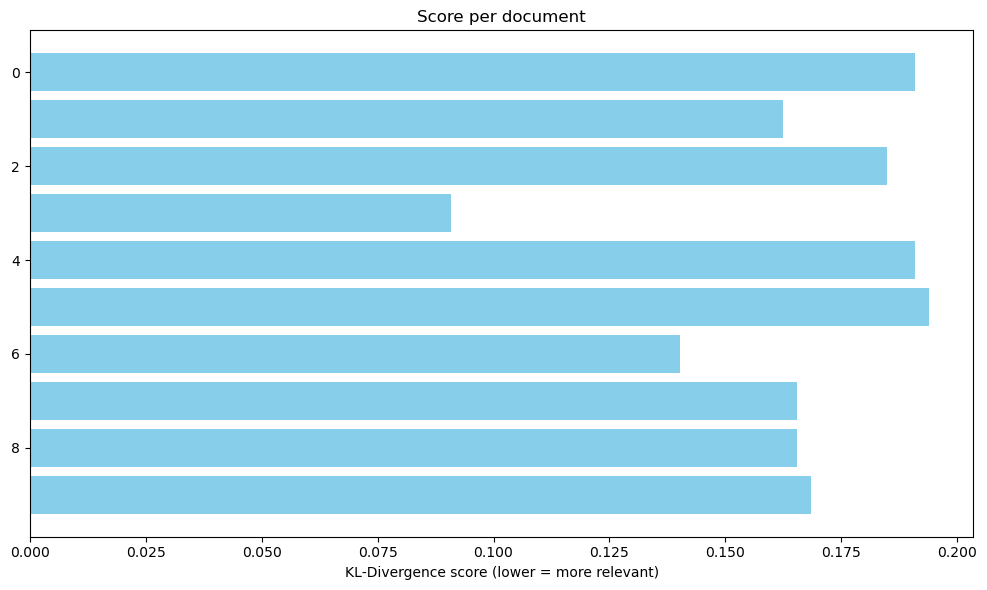

In [9]:
# Visualise scores for every document
scores = []
for i in range(len(docs)):
    s, _ = ranker._score_document(i)
    scores.append(s)
df_score = pd.DataFrame({
    "doc_id": range(len(docs)),
    "score": scores
})
plt.figure(figsize=(10,6))
plt.barh(df_score['doc_id'], df_score['score'], color='skyblue')
plt.xlabel('KL‑Divergence score (lower = more relevant)')
plt.title('Score per document')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

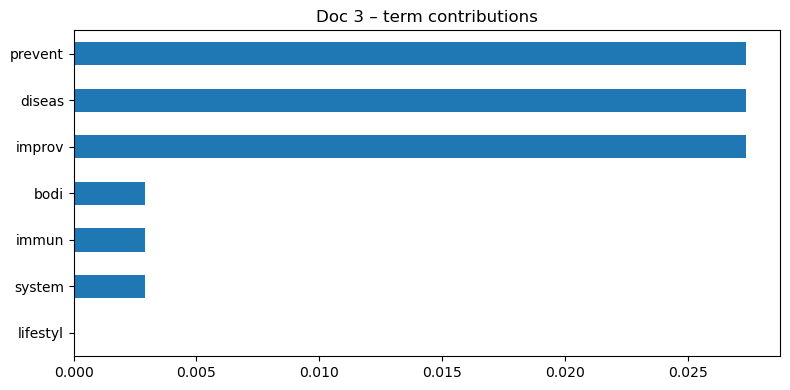

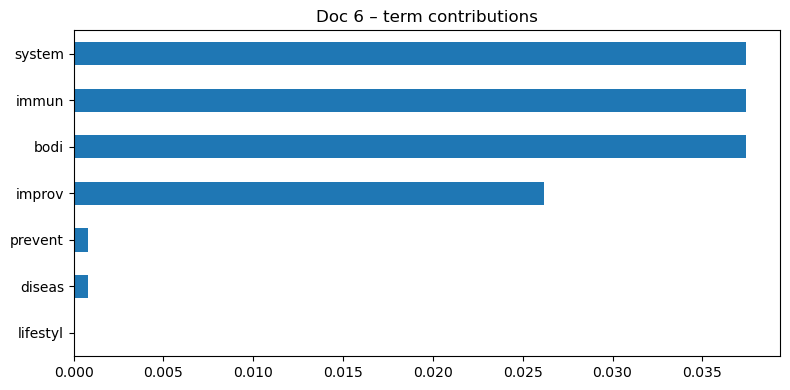

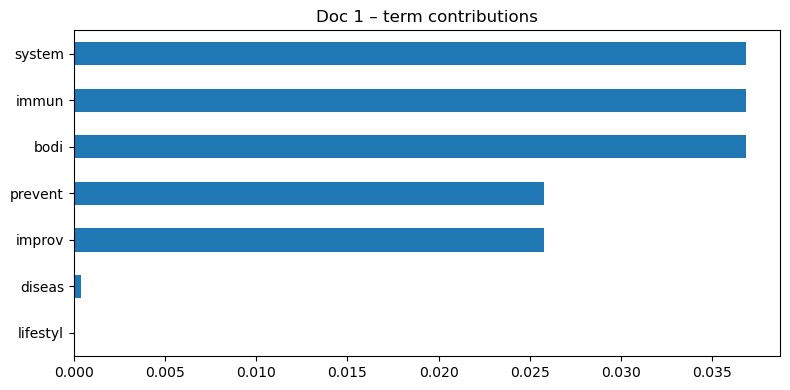

In [10]:
# Term contributions for each top document
for res in results:
    contrib = pd.DataFrame.from_dict(res['term_contributions'], orient='index', columns=['contribution'])
    contrib = contrib.sort_values('contribution', ascending=False)
    plt.figure(figsize=(8,4))
    contrib['contribution'].plot.barh()
    plt.title(f'Doc {res["doc_id"]} – term contributions')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

,doc_id,score,term_contributions
0,3,0.090802,"{'prevent': 0.02737543639755156, 'diseas': 0.0..."
1,6,0.140168,"{'prevent': 0.0008220151411129457, 'diseas': 0..."
2,1,0.162542,"{'prevent': 0.02576734736157512, 'diseas': 0.0..."


**Summary**

- The horizontal bar chart shows the KL‑Divergence score for every document; lower values indicate higher relevance.
- The top‑3 table lists the most relevant documents together with their scores.
- For each of those documents we visualise the per‑term contribution (IDF × P₍q₎ × log(P₍q₎/P₍d₎)). Positive contributions push the score up (less relevant) while negative contributions pull it down.
- These visualisations make it easy to understand why a particular document ranks where it does and which query terms drive the ranking.